In [1]:
import pandas as pd
import numpy as np
from IPython.display import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay
from transformers import Trainer, TrainingArguments
from stop_words import get_stop_words

In [2]:
train_df = pd.read_csv('data/train_df_clean.csv')
test_df = pd.read_csv('data/test_df_clean.csv')
dev_df = pd.read_csv('data/dev_df_clean.csv')

print(train_df.shape)
print(test_df.shape)
print(dev_df.shape)

(74726, 6)
(23353, 6)
(18682, 6)


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "google-bert/bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
def evaluate(y_pred, y_true):
  accuracy = accuracy_score(y_true, y_pred)
  macro_precision = precision_score(y_true, y_pred, zero_division=0,average='macro')
  macro_recall = recall_score(y_true, y_pred, zero_division=0,average='macro')
  micro_precision = precision_score(y_true, y_pred, zero_division=0,average='micro')
  micro_recall = recall_score(y_true, y_pred, zero_division=0,average='micro')
  micro_f1 = f1_score(y_true, y_pred, zero_division=0,average='micro')
  macro_f1 = f1_score(y_true, y_pred, zero_division=0,average='macro')
  cm = confusion_matrix(y_true, y_pred)

  print(f"\n{'='*70}")
  print("Detailed Evaluation Metrics:")
  print(f"{'='*70}")
  print(f"Accuracy: {accuracy*100:.2f}%")
  print(f"Macro Precision: {macro_precision:.4f}")
  print(f"Macro Recall: {macro_recall:.4f}")
  print(f"Micro Precision: {micro_precision:.4f}")
  print(f"Micro Recall: {micro_recall:.4f}")
  print(f"Macro F1-Score: {micro_f1:.4f}")
  print(f"Micro F1-Score: {macro_f1:.4f}")
  matrix_dsp = ConfusionMatrixDisplay(confusion_matrix=cm)
  matrix_dsp.plot(cmap='Blues',values_format='d')

In [5]:
def get_img(img_id,set_name): # set_name [train,test,dev]
    display(Image(filename=f'data/{set_name}/{img_id}.jpg'))

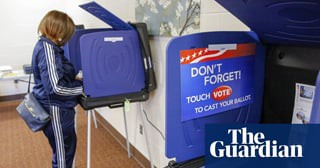

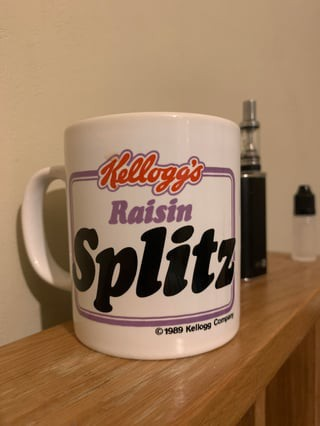

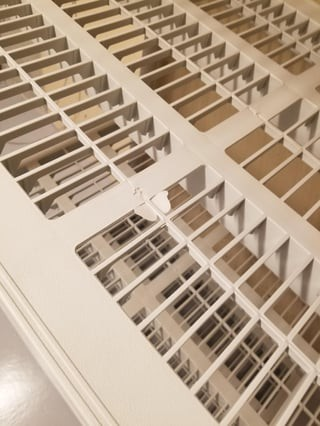

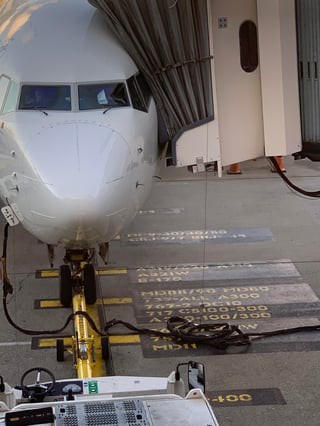

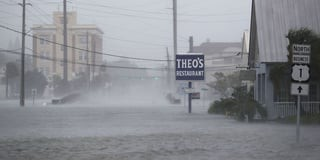

In [6]:

for ind,row in train_df.head(5).iterrows():
    get_img(row['id'],'train')

In [7]:
train_df.head()

,author,clean_title,id,2_way_label,3_way_label,6_way_label
0,FloopyDoopy,they think they are above the law the firms th...,bgjip0,1,0,0
1,mister10percent,this old kelloggs mug is years old,dl7luu,1,0,0
2,Klyuchak,this molding flash that looks like a butterfly,bu0gal,1,0,0
3,PooYaKasha,these tarmac markings that show where to park ...,bnvxjq,1,0,0
4,ruskeeblue,trump has no one in charge of fema or the noaa...,6w0q7n,1,0,0


In [8]:
#for this initial training we just want the 2_way_label and the text
train_df = train_df[["clean_title","2_way_label"]]
train_df = train_df.rename(columns={"2_way_label": "labels"})

In [9]:
#for this initial training we just want the 2_way_label and the text
dev_df = dev_df[["clean_title","2_way_label"]]
dev_df = dev_df.rename(columns={"2_way_label": "labels"})

In [10]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)


In [11]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

def tokenize_function(data):
    return tokenizer(
        data["clean_title"],
        padding="max_length",
        truncation=True
    )

In [12]:
from datasets import Dataset

#we convert to datasets because that is what hugging face train expects
train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(dev_df)

In [13]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
train_dataset = train_dataset.remove_columns(["clean_title"])
train_dataset

Map:   0%|          | 0/74726 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 74726
})

In [14]:
eval_dataset = eval_dataset.map(tokenize_function, batched=True)
eval_dataset = eval_dataset.remove_columns(["clean_title"])
eval_dataset

Map:   0%|          | 0/18682 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 18682
})

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

In [ ]:
trainer.train()

c:\Users\meedo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


In [ ]:
predictions = trainer.predict(eval_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)

pred_y = pd.Series(pred_labels)
true_y = pd.Series(predictions.label_ids)

In [ ]:
evaluate(pred_y,true_y)